> **Fixed version note**
>
> This version keeps the **original Titanic CSV source URL** and only fixes notebook bugs.
> Main repairs:
> - keeps the original remote Titanic dataset
> - adds a safe fallback to a local `data/titanic.csv` file if the URL is unavailable
> - imports `plot_tree`, which is used later in the notebook


In [1]:
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Вячеслав\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Вячеслав\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Вячеслав\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Вячеслав\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Load the Dataset
We first try the **original public Titanic CSV URL**. If that is unavailable, we fall back to a local `data/titanic.csv` file.

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
local_fallback = Path("data/titanic.csv")

try:
    titanic_df = pd.read_csv(url)
    print("Loaded Titanic dataset from the original public CSV URL.")
except Exception as e:
    if local_fallback.exists():
        titanic_df = pd.read_csv(local_fallback)
        print(f"Remote load failed ({type(e).__name__}). Loaded local fallback: {local_fallback}")
    else:
        raise RuntimeError(
            "Could not load the Titanic dataset from the original URL, "
            "and no local fallback file was found at data/titanic.csv."
        ) from e

# Display the first few rows
titanic_df.head()

Loaded Titanic dataset from the original public CSV URL.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Preprocessing
Linear regression models require numerical inputs and cannot handle missing values (NaNs). We will:
1. Select our features (`Pclass`, `Age`, `SibSp`, `Parch`) and target (`Fare`).
2. Fill missing `Age` values with the median age.
3. Drop any remaining rows with missing values just in case.

In [4]:
# Select features and target
features = ['Pclass', 'Age', 'SibSp', 'Parch']
target = 'Fare'

df = titanic_df[features + [target]].copy()

# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop any remaining missing values (if any exist)
df = df.dropna()

# Separate X (features) and y (target)
X = df[features]
y = df[target]

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (891, 5)


## 3. Train-Test Split

It is common in machine learning to split the dataset into a training set and a testing set. The training set is used to train the model, while the testing set is used to evaluate how well the model has learned to make predictions on unseen data.

We split our data into a training set (to teach the model) and a testing set (to evaluate how well it learned). We will use 80% of the data for training and 20% for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 712 rows
Testing data size: 179 rows


## 4. Train the Linear Regression Model
We instantiate the Linear Regression model from scikit-learn and fit it directly to our training data.

In [6]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display the learned coefficients
print("Intercept:", model.intercept_)
for feature, coef in zip(features, model.coef_):
    print(f"{feature} coefficient: {coef:.2f}")

Intercept: 113.75053411107666
Pclass coefficient: -36.03
Age coefficient: -0.15
SibSp coefficient: 5.26
Parch coefficient: 11.16


## 5. Visualize the Model Fit on Training Data
To draw a clean prediction line for a single feature in a multiple regression model, we have to hold the *other* features constant. 

Here, we plot the actual training data (teal dots). Then, we draw a prediction line (red) by varying the feature on the X-axis from its minimum to maximum value, while keeping all other features locked at their mean value. This isolates the linear effect of that specific feature on the Fare.

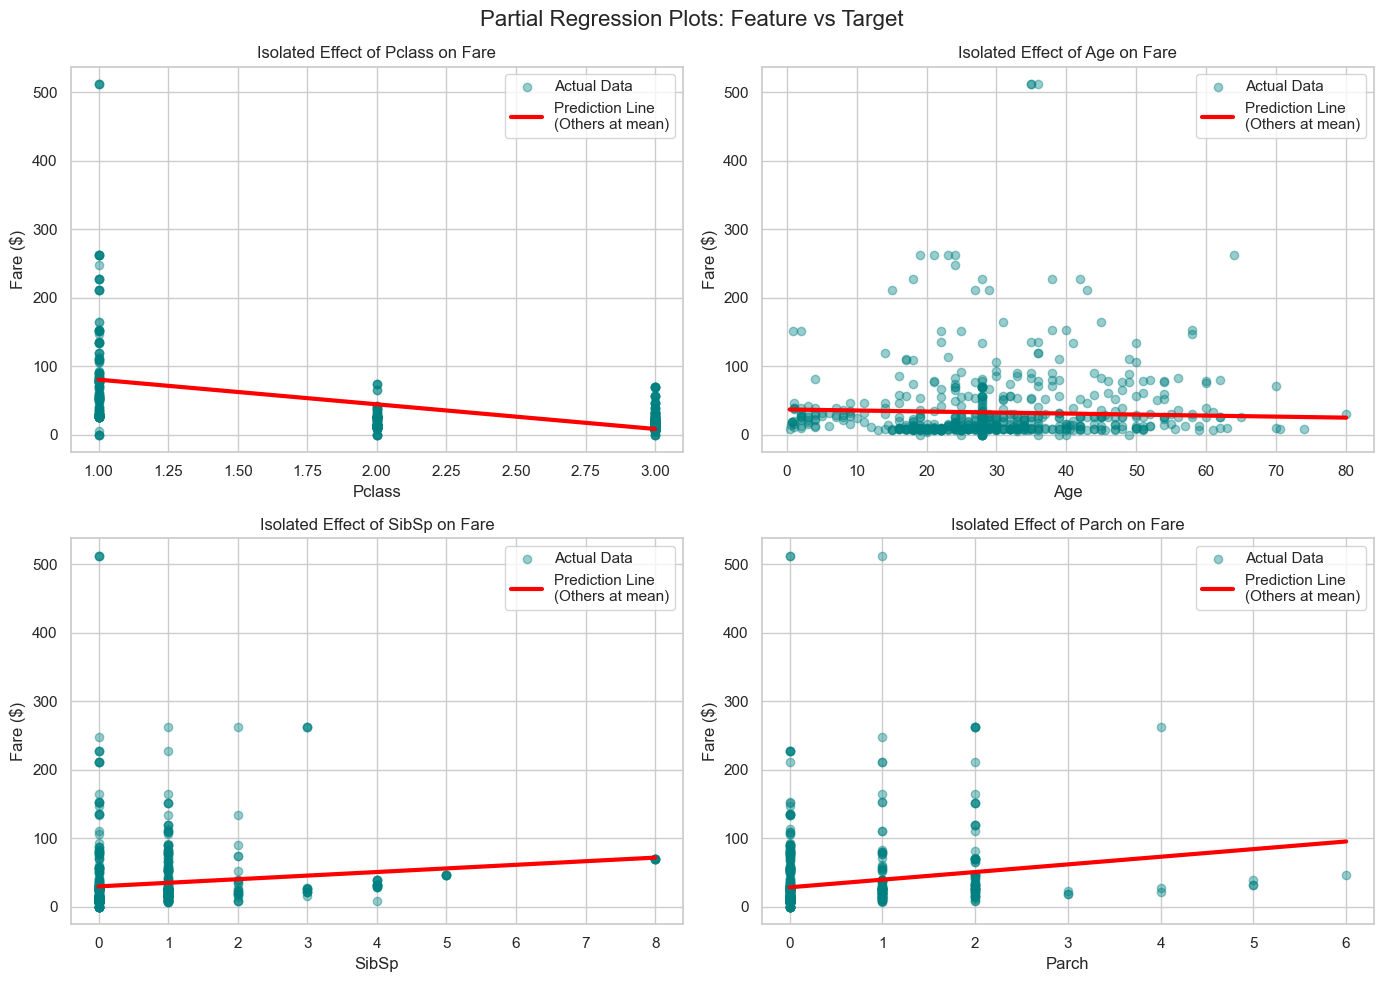

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Partial Regression Plots: Feature vs Target', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, feature in enumerate(features):
    # 1. Scatter plot of actual training data
    axes[i].scatter(X_train[feature], y_train, alpha=0.4, color='teal', label='Actual Data')
    
    # 2. Create a sequence of values for the current feature (min to max)
    x_vals = np.linspace(X_train[feature].min(), X_train[feature].max(), 100)
    
    # 3. Create synthetic data: vary current feature, hold others at their mean
    synthetic_data = pd.DataFrame(index=range(100), columns=features)
    for col in features:
        if col == feature:
            synthetic_data[col] = x_vals
        else:
            synthetic_data[col] = X_train[col].mean()
            
    # 4. Predict the target using the synthetic data
    y_line = model.predict(synthetic_data)
    
    # 5. Plot the isolated prediction line
    axes[i].plot(x_vals, y_line, color='red', linewidth=3, label='Prediction Line\n(Others at mean)')
    
    axes[i].set_title(f'Isolated Effect of {feature} on Fare')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Fare ($)')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 6. Model Evaluation
Finally, let's make predictions on our unseen test set and see how well our model performed using Mean Squared Error (MSE) and the R-squared metric.

Mean Squared Error (MSE): 946.34
R-squared (R2): 0.39


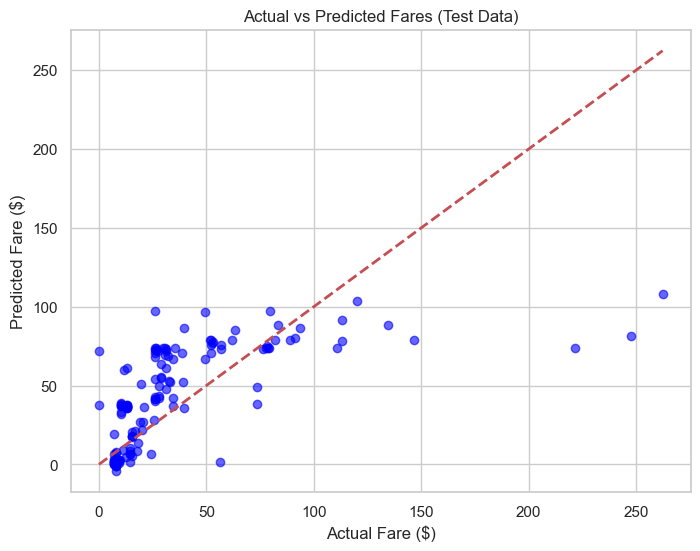

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize Actual vs Predicted on Test Set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.title('Actual vs Predicted Fares (Test Data)')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.show()

# Decision Tree Classification (Predicting Survival)

Now, let's look at a true classification problem. Instead of predicting the numerical `Fare`, we will predict whether a passenger `Survived` (1) or died (0).

To do this, we will pull the `Survived` column from our original dataset, create a new train-test split, and train a **Decision Tree Classifier**. Note that the evaluation metrics also change: instead of MSE and R-squared, we will look at **Accuracy** and a **Classification Report**.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prep the data for Classification
target_class = 'Survived'
df_class = titanic_df[features + [target_class]].copy()
df_class['Age'] = df_class['Age'].fillna(df_class['Age'].median())
df_class = df_class.dropna()

X_class = df_class[features]
y_class = df_class[target_class]

# 2. New Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# 3. Initialize and train the Classifier (max depth of 3 for visualization)
clf_model = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# 4. Predict on the test set
y_pred_c = clf_model.predict(X_test_c)

# 5. Evaluate
print("CLASSIFICATION PERFORMANCE:")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.2f}\n")
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c))

CLASSIFICATION PERFORMANCE:
Accuracy: 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.85      0.79       105
           1       0.73      0.59      0.66        74

    accuracy                           0.74       179
   macro avg       0.74      0.72      0.73       179
weighted avg       0.74      0.74      0.74       179



## Visualizing the Classification Tree
When we draw a classification tree, the terminal leaves don't show an average value anymore. Instead, they show the majority class (Died or Survived) for the passengers that ended up in that specific bucket.

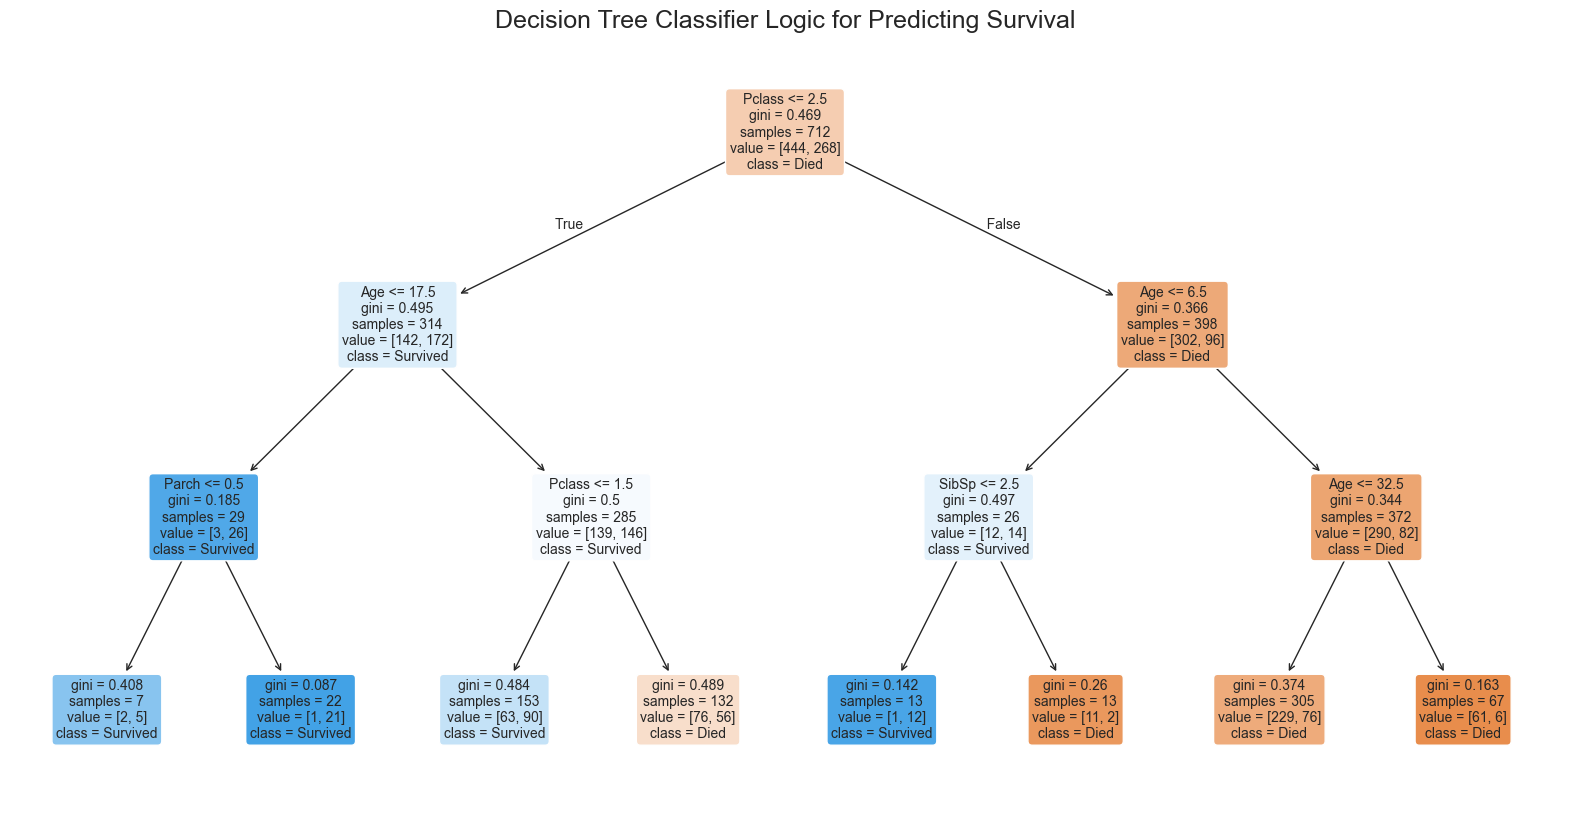

In [10]:
plt.figure(figsize=(20, 10))
plot_tree(clf_model, 
          feature_names=features, 
          class_names=['Died', 'Survived'], # We add class names here!
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Classifier Logic for Predicting Survival', fontsize=18)
plt.show()

# Unsupervised Learning: K-Means Clustering

We have looked at supervised learning (where we predict a specific target). Now, let's explore unsupervised learning with **K-Means Clustering**. 

K-Means groups passengers into `K` different clusters based on feature similarity. Because K-Means relies on distance calculations (like drawing a line between points), we must **scale** our features so that large numbers (like Fare) do not overpower small numbers (like Pclass).

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select features for clustering (we will include Fare this time)
cluster_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Create a clean dataframe for clustering
df_cluster = titanic_df[cluster_features].copy()
df_cluster['Age'] = df_cluster['Age'].fillna(df_cluster['Age'].median())
df_cluster = df_cluster.dropna()

# 2. Scale the Data (Crucial for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

## The Elbow Method
How do we know how many clusters (`K`) to use? We can use the **Elbow Method**. We run K-Means for 1 through 10 clusters and plot the "inertia" (how tightly packed the clusters are). We look for the "elbow" in the line graph where the rate of improvement sharply drops off.

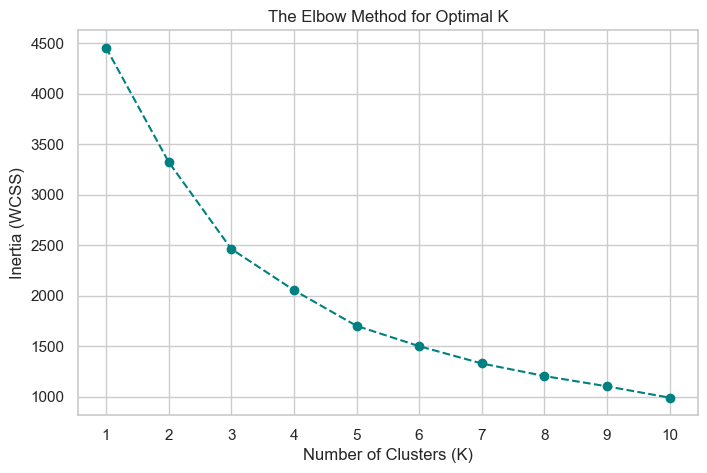

In [12]:
wcss = [] # Within-Cluster Sum of Square

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(range(1, 11))
plt.show()

## Applying K-Means and Visualizing
Looking at the elbow plot, a good choice for `K` is often around 3 or 4 for this dataset. Let's group the passengers into **3 clusters** and visualize how the algorithm separated them by plotting `Age` vs `Fare`.

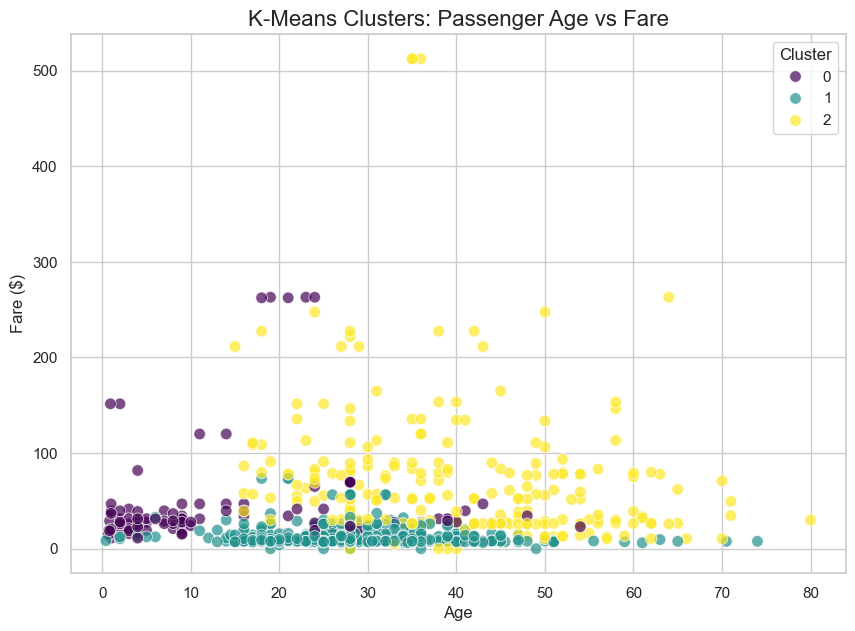

In [13]:
# 1. Initialize and fit the final K-Means model with K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Visualize the Clusters (Age vs Fare)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_cluster, 
                x='Age', 
                y='Fare', 
                hue='Cluster', 
                palette='viridis', 
                alpha=0.7,
                s=70)

plt.title('K-Means Clusters: Passenger Age vs Fare', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Fare ($)')
plt.legend(title='Cluster')
plt.show()

# Feature Engineering & Selection

Before training a model, we need to decide *which* features to give it. Including irrelevant features can introduce noise and cause the model to overfit. 

First, let's engineer a couple of new numeric features so we have more options to choose from:
1. **Sex_Code:** We will convert the text `Sex` column into numbers (Female = 1, Male = 0).
2. **FamilySize:** We will combine `SibSp` and `Parch` into a single variable representing total family members aboard.

In [14]:
# 1. Create a fresh copy of the dataset for feature engineering
df_fe = titanic_df.copy()

# 2. Handle missing values
df_fe['Age'] = df_fe['Age'].fillna(df_fe['Age'].median())
df_fe['Fare'] = df_fe['Fare'].fillna(df_fe['Fare'].median())

# 3. Engineer new numeric features
df_fe['Sex_Code'] = df_fe['Sex'].map({'female': 1, 'male': 0})
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

# Define our expanded list of potential features
potential_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_Code', 'FamilySize']

print("Engineered features successfully!")

Engineered features successfully!


## Technique 1: Correlation Heatmap
A correlation matrix measures the linear relationship between every pair of variables. We want to find features that have a strong positive or negative correlation with our target (`Survived`), while avoiding features that are highly correlated with *each other* (which provides redundant information).

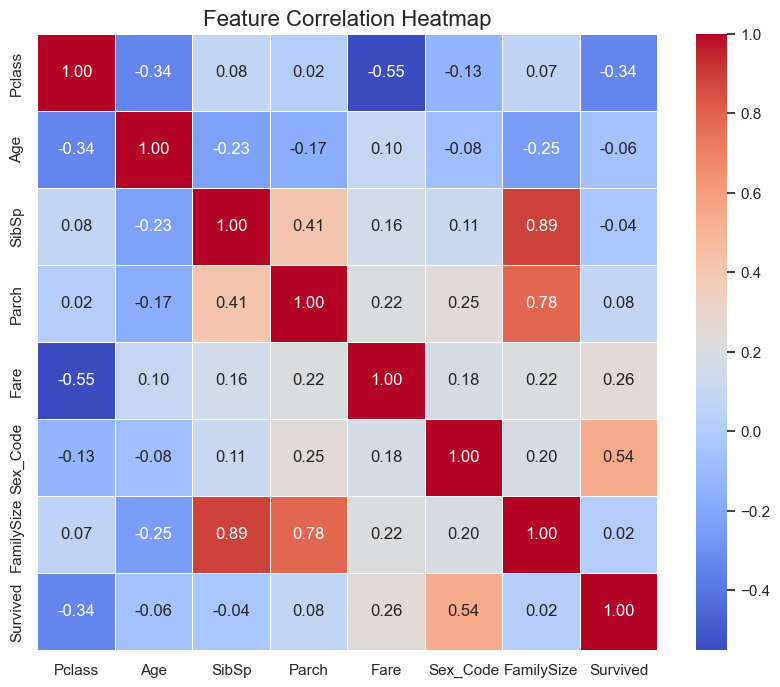

In [15]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df_fe[potential_features + ['Survived']].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

## Technique 2: Tree-Based Feature Importance
While heatmaps are great for finding linear relationships, Tree models (like Random Forests) can capture complex, non-linear relationships. We can train a quick Random Forest and ask it which features it relied on the most to make its splits.

C:\Users\Вячеслав\AppData\Local\Temp\ipykernel_17136\4089554201.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')


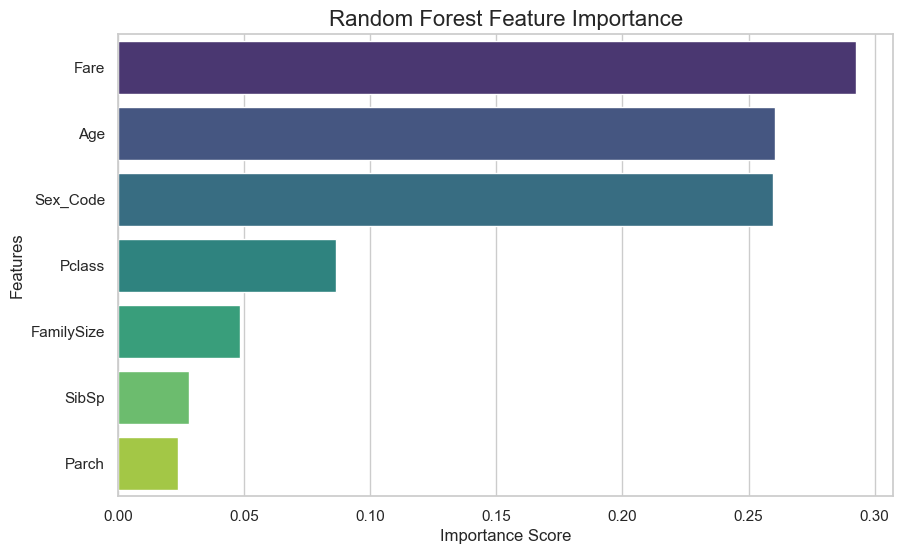

In [16]:
from sklearn.ensemble import RandomForestClassifier

# 1. Separate features and target
X_fe = df_fe[potential_features]
y_fe = df_fe['Survived']

# 2. Train a Random Forest Classifier
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_fe, y_fe)

# 3. Extract and sort feature importances
importances = pd.Series(rf_selector.feature_importances_, index=potential_features)
importances_sorted = importances.sort_values(ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')
plt.title('Random Forest Feature Importance', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Handling Outliers

Outliers are extreme values that fall far outside the normal range of your data. They can cause major issues, especially for distance-based algorithms (like K-Means) or models that try to minimize squared errors (like Linear Regression), because the model will twist itself to try and fit that one extreme point.

In the Titanic dataset, the `Fare` column is notorious for outliers. Let's visualize this using a **Boxplot**.

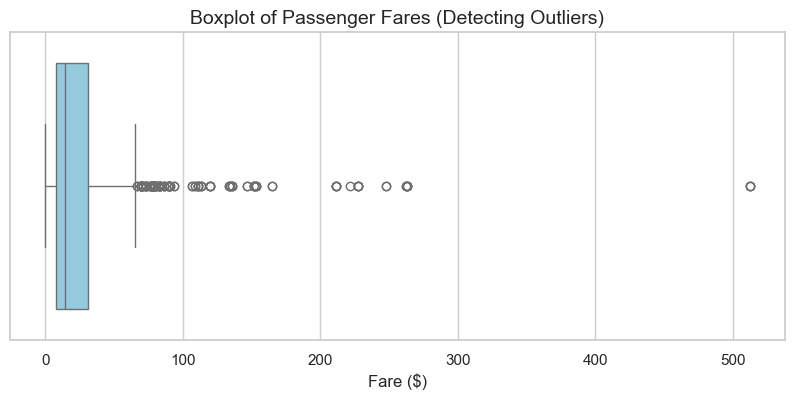

In [17]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_fe['Fare'], color='skyblue')
plt.title('Boxplot of Passenger Fares (Detecting Outliers)', fontsize=14)
plt.xlabel('Fare ($)')
plt.show()

## Identifying and Capping Outliers (IQR Method)
Looking at the boxplot, most fares are clustered under $100, but a few passengers paid over $500! 

To handle this, we will use the **Interquartile Range (IQR)** method. We will calculate the middle 50% of the data, determine an upper boundary, and instead of deleting the rich passengers (which means losing valuable data about their survival!), we will **cap** their fares at that upper boundary. This technique is called **Winsorizing**.

Upper Bound for Fare: $65.63
Number of outliers detected: 116


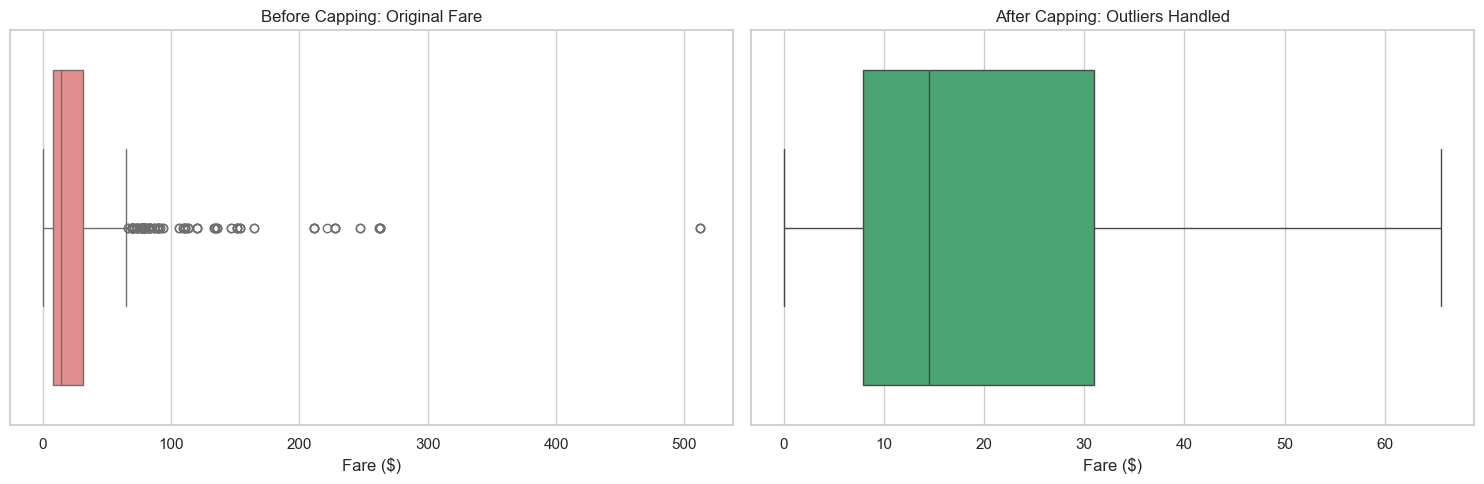

In [18]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_fe['Fare'].quantile(0.25)
Q3 = df_fe['Fare'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the upper bound (typically 1.5 * IQR above Q3)
upper_bound = Q3 + 1.5 * IQR
print(f"Upper Bound for Fare: ${upper_bound:.2f}")

# 3. Count how many outliers we have
outliers_count = (df_fe['Fare'] > upper_bound).sum()
print(f"Number of outliers detected: {outliers_count}")

# 4. Cap the outliers at the upper bound
df_fe['Fare_Capped'] = np.where(df_fe['Fare'] > upper_bound, upper_bound, df_fe['Fare'])

# 5. Visualize the "Before" and "After"
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df_fe['Fare'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before Capping: Original Fare')
axes[0].set_xlabel('Fare ($)')

sns.boxplot(x=df_fe['Fare_Capped'], ax=axes[1], color='mediumseagreen')
axes[1].set_title('After Capping: Outliers Handled')
axes[1].set_xlabel('Fare ($)')

plt.tight_layout()
plt.show()